## PROJET VISUALISATION DES DONNEES
### Les déterminants de l'espérance de vie
#### Ndeye BAKHOUM Master 1 Economie de la santé

In [1]:
# import des librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm

#### 1. Importation de la base de données

In [2]:
# Import de la base de données

base = pd.read_csv("C:/Users/HP/Downloads/BASE.csv", sep = ',' ) 
base.shape

(38, 10)

In [3]:
# Affichons les dix premiers observations

base.head(10)

,Pays,Esperance_vie,Depense_sante,Lits_hopitaux1000,Taux_chomage,PIB_reel,Taux_mortalite_infantile,Diplome_medecine,Consommation_alcool,Pollution_air
0,Japon,83.53,10.6590,8.6495,3.640000,0.844100,2.0,7.44,7.200,10.101480
1,Suisse,83.53,11.2020,4.6900,4.919180,1.911591,3.6,10.57,8.700,5.892591
2,Espagne,83.50,9.0130,2.9700,12.935000,2.915066,2.7,13.40,10.900,6.855799
3,Italie,83.40,8.7200,3.2000,11.750000,1.236233,2.8,13.36,7.100,7.262397
4,Luxembourg,82.70,5.3379,4.8200,6.333333,4.320402,3.8,12.03,11.500,17.312560
5,France,82.70,11.2572,6.0500,10.058330,0.860027,3.7,9.46,11.700,7.093895
6,Israël,82.50,7.0990,2.9900,4.808333,4.182277,3.1,7.44,3.265,9.846153
7,Norvège,82.50,10.5300,3.6800,4.908333,1.164716,2.2,11.08,6.000,10.189650
8,Suède,82.40,10.9820,2.3400,7.150000,2.131188,2.5,11.98,7.200,5.360955
9,Australie,82.40,10.0900,3.8400,5.714149,2.682877,3.1,15.95,10.100,19.947976


#### 2. Statistiques descriptives

In [4]:
# Informations sur le type de variables

base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pays                      38 non-null     object 
 1   Esperance_vie             38 non-null     float64
 2   Depense_sante             38 non-null     float64
 3   Lits_hopitaux1000         38 non-null     float64
 4   Taux_chomage              38 non-null     float64
 5   PIB_reel                  38 non-null     float64
 6   Taux_mortalite_infantile  38 non-null     float64
 7   Diplome_medecine          38 non-null     float64
 8   Consommation_alcool       38 non-null     float64
 9   Pollution_air             38 non-null     float64
dtypes: float64(9), object(1)
memory usage: 3.1+ KB


In [5]:
# Statistiques descriptives

base.describe()

,Esperance_vie,Depense_sante,Lits_hopitaux1000,Taux_chomage,PIB_reel,Taux_mortalite_infantile,Diplome_medecine,Consommation_alcool,Pollution_air
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,80.477895,8.633742,4.341895,7.153003,2.392964,4.081053,12.308184,8.674474,10.084473
std,2.600796,1.890952,2.025306,2.686907,0.997489,2.196809,2.963541,2.570223,4.389803
min,74.900000,5.337900,1.651500,3.640000,0.844100,1.985000,7.440000,3.265000,5.097015
25%,78.800000,7.000750,2.755000,4.902083,1.784233,2.800000,10.287500,7.200000,6.543152
50%,81.500000,8.644500,3.760000,6.759123,2.320943,3.450000,12.030000,9.150000,9.153358
75%,82.400000,10.454750,5.775000,9.149166,3.033609,4.200000,14.885000,10.800000,11.931855
max,83.530000,11.257200,8.649500,12.935000,4.320402,10.255000,17.160500,11.700000,19.947976


#### 3. Visualisation de la distribution de certaines variables

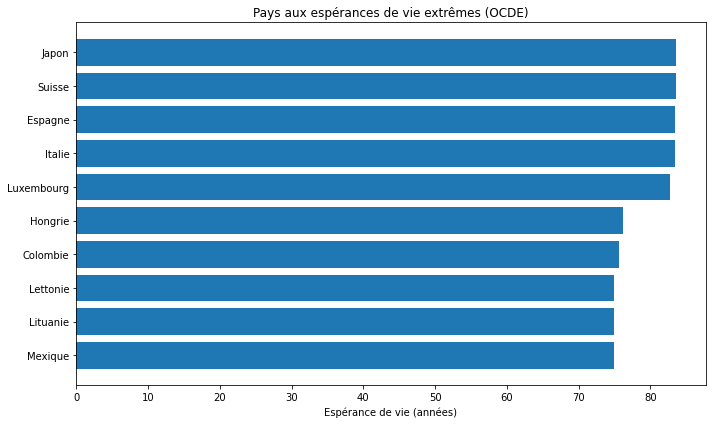

In [6]:
# Graphique avec les espérance de vie extreme(plus faible et plus élevé )

df_sorted = base.sort_values("Esperance_vie")

# 5 pays avec espérance de vie la plus faible
low_5 = df_sorted.head(5)

# 5 pays avec espérance de vie la plus élevée
high_5 = df_sorted.tail(5)

df_extremes = pd.concat([low_5, high_5])

plt.figure(figsize=(10,6))
plt.barh(df_extremes["Pays"], df_extremes["Esperance_vie"])
plt.xlabel("Espérance de vie (années)")
plt.title("Pays aux espérances de vie extrêmes (OCDE)")
plt.tight_layout()
plt.show()


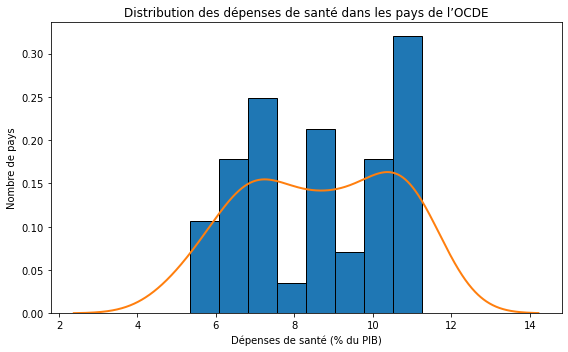

In [7]:
# Distribution des dépenses de santé

plt.figure(figsize=(8,5))

# Histogramme normalisé
plt.hist(
    base["Depense_sante"],
    bins=8,
    density=True,      
    rwidth=1,
    edgecolor="black"
)

# Courbe de densité
base["Depense_sante"].plot(kind="kde", linewidth=2)

plt.xlabel("Dépenses de santé (% du PIB)")
plt.ylabel("Nombre de pays")
plt.title("Distribution des dépenses de santé dans les pays de l’OCDE")

plt.tight_layout()
plt.show()


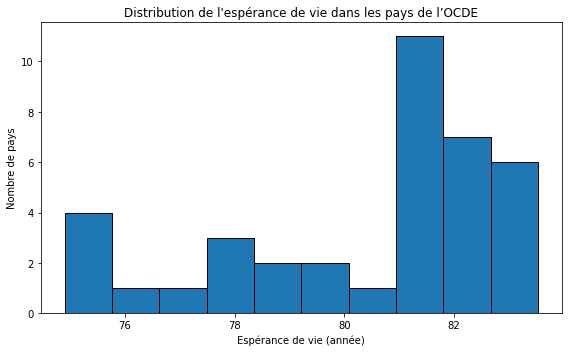

In [8]:
# Distribution de l'espérance de vie

plt.figure(figsize=(8,5))

plt.hist(
    base["Esperance_vie"],
    bins=10,
    rwidth=1,
    edgecolor="black"   
)

plt.xlabel("Espérance de vie (année)")
plt.ylabel("Nombre de pays")
plt.title("Distribution de l'espérance de vie dans les pays de l’OCDE")

plt.tight_layout()
plt.show()


#### 4. Corrélations entre variables

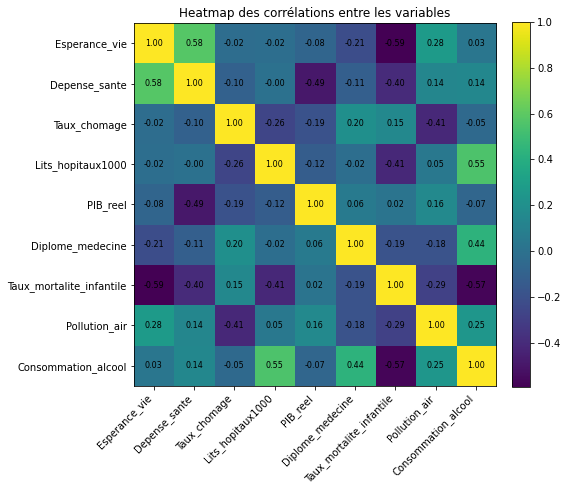

In [9]:
# Corrélattion entre les données

# Sélection des variables quantitatives
variables = ["Esperance_vie", "Depense_sante","Taux_chomage","Lits_hopitaux1000", "PIB_reel",
             "Diplome_medecine","Taux_mortalite_infantile","Pollution_air","Consommation_alcool"]

df_corr = base[variables].corr()

# Création du heatmap
plt.figure(figsize=(8,8))
im = plt.imshow(df_corr)

# Ajouter la barre de couleur
plt.colorbar(im, fraction=0.046, pad=0.04)

# Ajouter les labels
plt.xticks(range(len(variables)), variables, rotation=45, ha="right")
plt.yticks(range(len(variables)), variables)

# Ajouter les valeurs de corrélation
for i in range(len(variables)):
    for j in range(len(variables)):
        plt.text(j, i, f"{df_corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Heatmap des corrélations entre les variables")
plt.tight_layout()
plt.show()


#### 5. Analyse de l’homogénéité des données

C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


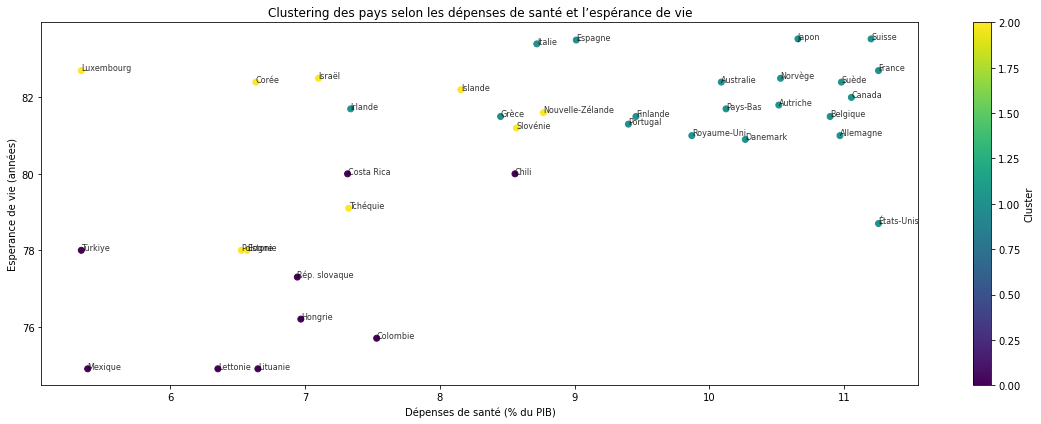

In [10]:
# Cluster des variables

# Variables utilisées pour le clustering
variables_cluster = [ "Esperance_vie","PIB_reel","Taux_mortalite_infantile","Depense_sante"]

X = base[variables_cluster]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-means (choix de 3 clusters, classique et lisible)
kmeans = KMeans(n_clusters=3, random_state=42)
base["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(16,6))

scatter = plt.scatter(
    base["Depense_sante"],
    base["Esperance_vie"],
    c=base["Cluster"]
)

# Ajouter le nom des pays
for i in range(len(base)):
    plt.text(
        base["Depense_sante"].iloc[i],
        base["Esperance_vie"].iloc[i],
        base["Pays"].iloc[i],
        fontsize=8,
        alpha=0.8
    )

plt.xlabel("Dépenses de santé (% du PIB)")
plt.ylabel("Esperance de vie (années)")
plt.title("Clustering des pays selon les dépenses de santé et l’espérance de vie")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()




#### Enrichissement des données

In [11]:
#### Variables combinées

# Indice de resources médicales

base["Indice_ressources_medicales"] = (
    base["Lits_hopitaux1000"] +
    base["Diplome_medecine"] / 100
)

In [12]:
# Indice de vulnérabilité sanitaire

from sklearn.preprocessing import StandardScaler

vars_risque = base[[
    "Taux_mortalite_infantile",
    "Pollution_air",
    "Consommation_alcool"
]]

scaler = StandardScaler()
vars_scaled = scaler.fit_transform(vars_risque)

base["Indice_vulnerabilite"] = vars_scaled.mean(axis=1)

In [13]:
# Variables dérivées

# Trnsformation de la variable PIB en Logarithme

base["Log_PIB"] = np.log(base["PIB_reel"])

In [14]:
base.head(5)

,Pays,Esperance_vie,Depense_sante,Lits_hopitaux1000,Taux_chomage,PIB_reel,Taux_mortalite_infantile,Diplome_medecine,Consommation_alcool,Pollution_air,Cluster,Indice_ressources_medicales,Indice_vulnerabilite,Log_PIB
0,Japon,83.53,10.6590,8.6495,3.640000,0.844100,2.0,7.44,7.2,10.101480,1,8.7239,-0.512491,-0.169485
1,Suisse,83.53,11.2020,4.6900,4.919180,1.911591,3.6,10.57,8.7,5.892591,1,4.7957,-0.393195,0.647936
2,Espagne,83.50,9.0130,2.9700,12.935000,2.915066,2.7,13.40,10.9,6.855799,1,3.1040,-0.168319,1.069893
3,Italie,83.40,8.7200,3.2000,11.750000,1.236233,2.8,13.36,7.1,7.262397,1,3.3336,-0.621092,0.212069
4,Luxembourg,82.70,5.3379,4.8200,6.333333,4.320402,3.8,12.03,11.5,17.312560,2,4.9403,0.884366,1.463349


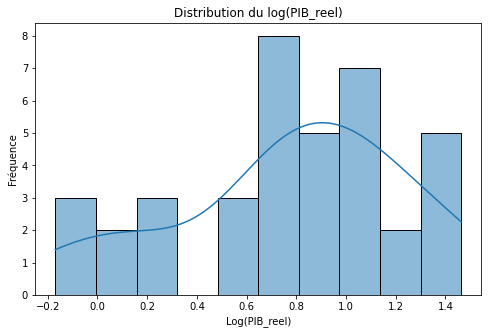

In [15]:
## Histogramme du log(PIB reel)

plt.figure(figsize=(8,5))
sns.histplot(base["Log_PIB"], bins=10, kde=True)

plt.title("Distribution du log(PIB_reel)")
plt.xlabel("Log(PIB_reel)")
plt.ylabel("Fréquence")
plt.show()

In [16]:
## Données externes

# Indices de GINI

df_gini = pd.read_excel("C:/Users/HP/Downloads/Base_gini.xlsx")
Base1 = base.merge(df_gini[["Pays","I_GINI"]], on="Pays", how="left")

In [17]:
Base1.head(5)

,Pays,Esperance_vie,Depense_sante,Lits_hopitaux1000,Taux_chomage,PIB_reel,Taux_mortalite_infantile,Diplome_medecine,Consommation_alcool,Pollution_air,Cluster,Indice_ressources_medicales,Indice_vulnerabilite,Log_PIB,I_GINI
0,Japon,83.53,10.6590,8.6495,3.640000,0.844100,2.0,7.44,7.2,10.101480,1,8.7239,-0.512491,-0.169485,31.8
1,Suisse,83.53,11.2020,4.6900,4.919180,1.911591,3.6,10.57,8.7,5.892591,1,4.7957,-0.393195,0.647936,33.0
2,Espagne,83.50,9.0130,2.9700,12.935000,2.915066,2.7,13.40,10.9,6.855799,1,3.1040,-0.168319,1.069893,35.8
3,Italie,83.40,8.7200,3.2000,11.750000,1.236233,2.8,13.36,7.1,7.262397,1,3.3336,-0.621092,0.212069,35.2
4,Luxembourg,82.70,5.3379,4.8200,6.333333,4.320402,3.8,12.03,11.5,17.312560,2,4.9403,0.884366,1.463349,31.7


In [18]:
Base1 = Base1.dropna(subset=["I_GINI"])

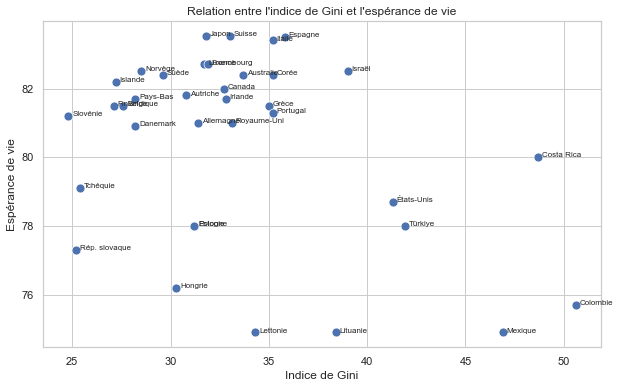

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(x=Base1["I_GINI"], y=Base1["Esperance_vie"], s=80)

for i in range(len(Base1)):
    plt.text(Base1["I_GINI"].iloc[i]+0.2,
             Base1["Esperance_vie"].iloc[i],
             Base1["Pays"].iloc[i],
             fontsize=8)

plt.title("Relation entre l'indice de Gini et l'espérance de vie")
plt.xlabel("Indice de Gini")
plt.ylabel("Espérance de vie")

plt.show()

#### Analyse d'impact des variables explicatives sur le KPI

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Y = Base1["Esperance_vie"]
X_scaled = scaler.fit_transform(Base1[[
    "Log_PIB",
    "Depense_sante",
    "Taux_chomage",
    "Indice_ressources_medicales",
    "Indice_vulnerabilite",
    "I_GINI"
]])

X_scaled = sm.add_constant(X_scaled)
model = sm.OLS(Y, X_scaled).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Esperance_vie   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     3.650
Date:                Sun, 08 Mar 2026   Prob (F-statistic):            0.00804
Time:                        17:42:24   Log-Likelihood:                -75.750
No. Observations:                  36   AIC:                             165.5
Df Residuals:                      29   BIC:                             176.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         80.4600      0.368    218.369      0.0

#### Projection des données

In [29]:
from sklearn.decomposition import PCA


# Variables utilisées pour la projection
variables = [
    "Log_PIB",
    "Depense_sante",
    "Indice_ressources_medicales",
    "Indice_vulnerabilite",
    "I_GINI"
]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Base1[variables])

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Création dataframe
pca_df = pd.DataFrame(X_pca, columns=["Axe 1", "Axe 2"])
pca_df["Pays"] = Base1["Pays"]

print("Variance expliquée :", pca.explained_variance_ratio_)

Variance expliquée : [0.34638133 0.2653697 ]


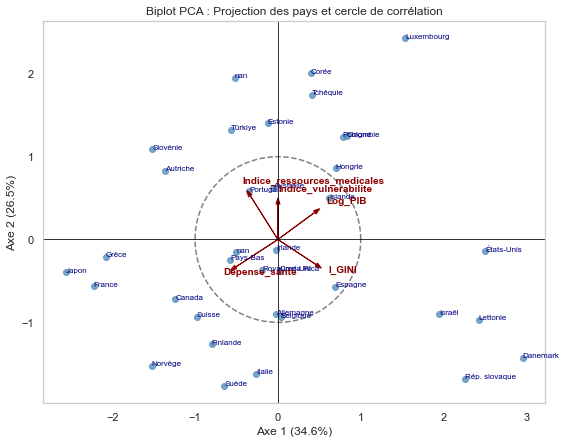

In [30]:
plt.figure(figsize=(9,9))

# --- 1️⃣ Projection des pays (bleu clair) ---
plt.scatter(pca_df["Axe 1"], pca_df["Axe 2"], 
            color="steelblue", alpha=0.7)

for i in range(len(pca_df)):
    plt.text(pca_df["Axe 1"][i],
             pca_df["Axe 2"][i],
             pca_df["Pays"][i],
             fontsize=8,
             color="navy")

# --- 2️⃣ Cercle de corrélation (gris) ---
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 
         color="gray", linestyle="--")

# --- 3️⃣ Flèches des variables (rouge) ---
loadings = pca.components_.T

for i, var in enumerate(variables):
    plt.arrow(0, 0,
              loadings[i, 0],
              loadings[i, 1],
              color="darkred",
              head_width=0.05,
              length_includes_head=True)
    
    plt.text(loadings[i, 0]*1.15,
             loadings[i, 1]*1.15,
             var,
             color="darkred",
             fontsize=10,
             fontweight="bold")

# Axes
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel(f"Axe 1 ({round(pca.explained_variance_ratio_[0]*100,1)}%)")
plt.ylabel(f"Axe 2 ({round(pca.explained_variance_ratio_[1]*100,1)}%)")
plt.title("Biplot PCA : Projection des pays et cercle de corrélation")

plt.gca().set_aspect('equal', adjustable='box')
plt.grid(alpha=0.2)

plt.show()

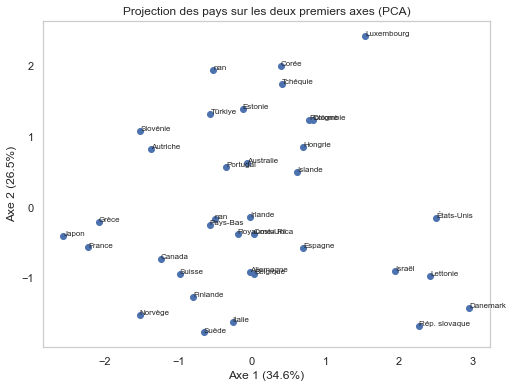

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(pca_df["Axe 1"], pca_df["Axe 2"])

for i in range(len(pca_df)):
    plt.text(pca_df["Axe 1"][i], 
             pca_df["Axe 2"][i], 
             pca_df["Pays"][i],
             fontsize=8)

plt.xlabel(f"Axe 1 ({round(pca.explained_variance_ratio_[0]*100,1)}%)")
plt.ylabel(f"Axe 2 ({round(pca.explained_variance_ratio_[1]*100,1)}%)")
plt.title("Projection des pays sur les deux premiers axes (PCA)")
plt.grid(alpha=0.3)
plt.show()

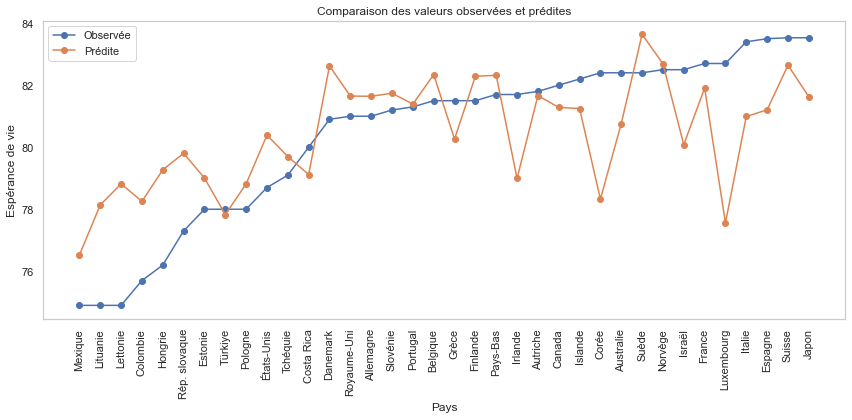

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prédictions
y_pred = model.fittedvalues

# Création d’un dataframe comparatif
df_compare = pd.DataFrame({
    "Pays": Base1["Pays"],
    "Observe": Y,
    "Predite": y_pred
})

# Trier par valeur observée pour meilleure lecture
df_compare = df_compare.sort_values(by="Observe").reset_index(drop=True)

# Graphique
plt.figure(figsize=(12,6))

plt.plot(df_compare["Pays"], df_compare["Observe"], marker='o')
plt.plot(df_compare["Pays"], df_compare["Predite"], marker='o')

plt.xticks(rotation=90)
plt.xlabel("Pays")
plt.ylabel("Espérance de vie")
plt.title("Comparaison des valeurs observées et prédites")
plt.legend(["Observée", "Prédite"])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()